# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- **Nama:** Adam Waluyo
- **Email:** adamwaluyo01@gmail.com
- **Id Dicoding:** adam_waluyo_7laR

Proyek ini membantu **Jaya Jaya Institut** mendeteksi mahasiswa yang berpotensi *dropout* sedini mungkin sehingga tim akademik dapat melakukan intervensi seperti konseling, bantuan akademik, dan dukungan finansial.

## Business Understanding

Jaya Jaya Institut menghadapi masalah tingginya jumlah mahasiswa yang tidak menyelesaikan studi. Dropout berdampak pada keberhasilan akademik mahasiswa, efektivitas layanan institusi, dan performa institusi secara keseluruhan. Dataset yang digunakan berisi data saat pendaftaran, faktor demografi/sosial-ekonomi, serta performa akademik semester pertama dan kedua.

### Permasalahan Bisnis
1. Institusi belum memiliki mekanisme berbasis data untuk mengidentifikasi mahasiswa yang berpotensi dropout.
2. Institusi membutuhkan dashboard yang mudah digunakan untuk memonitor karakteristik dan faktor yang berkaitan dengan dropout.
3. Tim akademik membutuhkan prototype machine learning yang dapat memberikan estimasi risiko dropout untuk mendukung prioritas intervensi.

### Cakupan Proyek
- Melakukan data understanding dan exploratory data analysis.
- Menyiapkan data untuk analisis, dashboard, dan machine learning.
- Membuat model klasifikasi **Dropout vs Graduate** menggunakan mahasiswa yang outcome akhirnya sudah diketahui. Mahasiswa berstatus `Enrolled` **tidak digunakan untuk training** karena outcome akhirnya belum diketahui.
- Model hanya menggunakan data yang tersedia paling lambat setelah semester pertama agar tetap relevan sebagai *early warning*.
- Membandingkan Logistic Regression dan Random Forest, lalu memilih model berdasarkan F1-score kelas dropout dengan mempertimbangkan recall.
- Menyimpan model ke `model/dropout_model.joblib`.
- Menyiapkan `dashboard_student_performance.csv` untuk business dashboard.
- Menyediakan prototype Streamlit melalui `app.py`.


## Persiapan

### Menyiapkan library yang dibutuhkan

Notebook menggunakan pandas/numpy untuk pengolahan data, matplotlib/seaborn untuk visualisasi, dan scikit-learn untuk preprocessing, modeling, serta evaluasi. Model disimpan menggunakan joblib.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
DATA_URL = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv'

pd.set_option('display.max_columns', 100)

### Menyiapkan data yang akan digunakan

Notebook akan memprioritaskan file lokal `data/data.csv`. Jika file tersebut belum tersedia (misalnya saat dijalankan di Google Colab), notebook otomatis membaca dataset resmi Dicoding dari GitHub.

In [2]:
local_candidates = [Path('data/data.csv'), Path('data.csv')]
local_path = next((p for p in local_candidates if p.exists()), None)

if local_path:
    df = pd.read_csv(local_path, sep=';')
    print(f'Dataset dibaca dari: {local_path}')
else:
    df = pd.read_csv(DATA_URL, sep=';')
    print('Dataset dibaca dari repository resmi Dicoding.')

print('Ukuran data:', df.shape)
display(df.head())

Dataset dibaca dari: data/data.csv
Ukuran data: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Tahap ini memeriksa struktur, tipe data, duplikasi, missing values, distribusi target, dan beberapa pola utama yang berkaitan dengan dropout. Dataset resmi terdiri dari 4.424 mahasiswa dan 36 fitur, dengan target awal tiga kelas: `Dropout`, `Enrolled`, dan `Graduate`.

In [3]:
print('Informasi dataframe:')
df.info()

print()
print('Jumlah missing value:', int(df.isna().sum().sum()))
print('Jumlah baris duplikat:', int(df.duplicated().sum()))

print()
print('Distribusi Status:')
status_summary = df['Status'].value_counts().to_frame('Jumlah')
status_summary['Persentase'] = (status_summary['Jumlah'] / len(df) * 100).round(2)
display(status_summary)

Informasi dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                     

,Jumlah,Persentase
Status,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


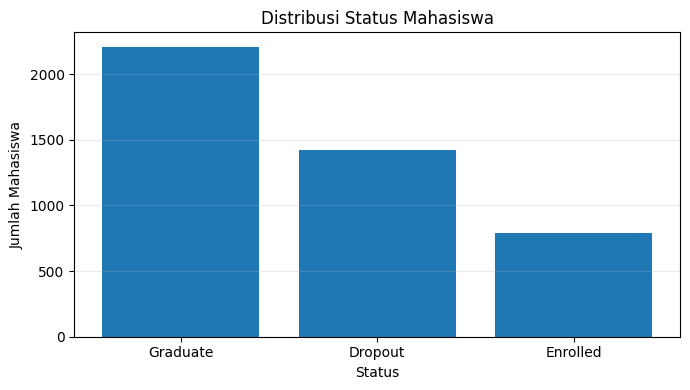

In [4]:
counts = df['Status'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index.astype(str), counts.values)
ax.set_title('Distribusi Status Mahasiswa')
ax.set_xlabel('Status')
ax.set_ylabel('Jumlah Mahasiswa')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA)

Untuk **dashboard dan analisis deskriptif**, seluruh 4.424 baris tetap dipertahankan agar institusi dapat memonitor status mahasiswa `Dropout`, `Enrolled`, dan `Graduate` secara keseluruhan. Indikator `Is_Dropout` hanya digunakan untuk menghitung dropout rate pada dashboard.

Namun, **dataset modeling dipisahkan pada tahap Data Preparation**: hanya mahasiswa berstatus `Dropout` dan `Graduate` yang digunakan untuk training karena keduanya sudah memiliki outcome final. Status `Enrolled` tidak diperlakukan sebagai kelas negatif.

Visualisasi berikut memeriksa faktor finansial dan akademik semester pertama yang relevan sebagai sinyal early warning. Hubungan yang terlihat bersifat **asosiasi/deskriptif**, bukan bukti sebab-akibat.


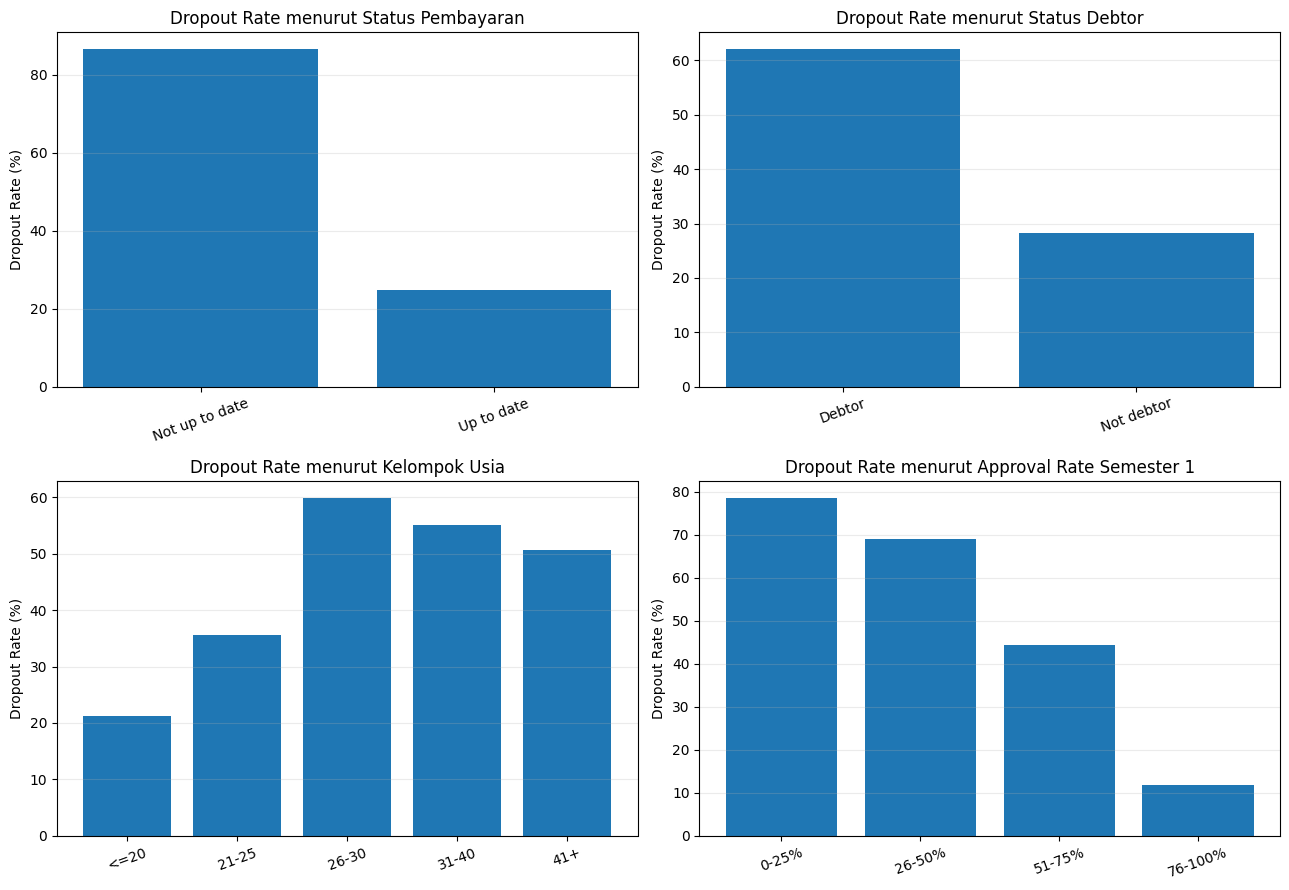

In [5]:
eda = df.copy()
eda['Is_Dropout'] = (eda['Status'] == 'Dropout').astype(int)
eda['Tuition_Status'] = eda['Tuition_fees_up_to_date'].map({1: 'Up to date', 0: 'Not up to date'})
eda['Debtor_Status'] = eda['Debtor'].map({1: 'Debtor', 0: 'Not debtor'})
eda['Scholarship_Status'] = eda['Scholarship_holder'].map({1: 'Scholarship', 0: 'No scholarship'})
eda['AgeGroup'] = pd.cut(
    eda['Age_at_enrollment'],
    bins=[0, 20, 25, 30, 40, 100],
    labels=['<=20', '21-25', '26-30', '31-40', '41+']
)

# Avoid division by zero when no units were enrolled.
eda['FirstSemApprovalRate'] = np.where(
    eda['Curricular_units_1st_sem_enrolled'] > 0,
    eda['Curricular_units_1st_sem_approved'] / eda['Curricular_units_1st_sem_enrolled'],
    0
)
eda['FirstSemApprovalBand'] = pd.cut(
    eda['FirstSemApprovalRate'],
    bins=[-0.01, 0.25, 0.5, 0.75, 1.0],
    labels=['0-25%', '26-50%', '51-75%', '76-100%']
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_specs = [
    (axes[0,0], 'Tuition_Status', 'Dropout Rate menurut Status Pembayaran'),
    (axes[0,1], 'Debtor_Status', 'Dropout Rate menurut Status Debtor'),
    (axes[1,0], 'AgeGroup', 'Dropout Rate menurut Kelompok Usia'),
    (axes[1,1], 'FirstSemApprovalBand', 'Dropout Rate menurut Approval Rate Semester 1'),
]

for ax, col, title in plot_specs:
    temp = eda.groupby(col, observed=False)['Is_Dropout'].mean().mul(100)
    labels = temp.index.astype(str)
    ax.bar(labels, temp.values)
    ax.set_title(title)
    ax.set_ylabel('Dropout Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [6]:
# Tabel ringkas untuk membantu interpretasi EDA.
for col in ['Tuition_Status', 'Debtor_Status', 'Scholarship_Status', 'AgeGroup', 'FirstSemApprovalBand']:
    summary = (
        eda.groupby(col, observed=False)
        .agg(Total=('Is_Dropout', 'size'), Dropout=('Is_Dropout', 'sum'), Dropout_Rate=('Is_Dropout', 'mean'))
        .reset_index()
    )
    summary['Dropout_Rate'] = (summary['Dropout_Rate'] * 100).round(2)
    print()
    print(col)
    display(summary)


Tuition_Status


,Tuition_Status,Total,Dropout,Dropout_Rate
0,Not up to date,528,457,86.55
1,Up to date,3896,964,24.74



Debtor_Status


,Debtor_Status,Total,Dropout,Dropout_Rate
0,Debtor,503,312,62.03
1,Not debtor,3921,1109,28.28



Scholarship_Status


,Scholarship_Status,Total,Dropout,Dropout_Rate
0,No scholarship,3325,1287,38.71
1,Scholarship,1099,134,12.19



AgeGroup


,AgeGroup,Total,Dropout,Dropout_Rate
0,<=20,2551,542,21.25
1,21-25,828,295,35.63
2,26-30,383,229,59.79
3,31-40,437,241,55.15
4,41+,225,114,50.67



FirstSemApprovalBand


,FirstSemApprovalBand,Total,Dropout,Dropout_Rate
0,0-25%,847,665,78.51
1,26-50%,294,203,69.05
2,51-75%,509,226,44.40
3,76-100%,2774,327,11.79


## Data Preparation / Preprocessing

Tahap ini memisahkan kebutuhan **dashboard** dan **machine learning**.

- Untuk dashboard, seluruh status (`Dropout`, `Enrolled`, `Graduate`) tetap dapat digunakan untuk monitoring.
- Untuk machine learning, data difilter sehingga **hanya `Dropout` dan `Graduate`** yang masuk ke proses training. Mahasiswa `Enrolled` memiliki outcome yang belum final sehingga disimpan terpisah dan **tidak digunakan untuk training**.
- Target binary ditetapkan sebagai `Dropout = 1` dan `Graduate = 0`.
- Distribusi target diverifikasi sebelum split, lalu `train_test_split(..., stratify=y)` digunakan agar proporsi kelas terjaga pada train dan test.

Untuk menjaga prototype tetap mudah digunakan dan sesuai tujuan *early warning*, model hanya memakai data pendaftaran, faktor finansial/demografi, dan performa **semester pertama**. Informasi semester kedua sengaja tidak digunakan agar prediksi dapat dilakukan lebih dini.

Fitur kategorikal di-*one-hot encode*, fitur numerik diimputasi dan distandardisasi untuk Logistic Regression. Pipeline memastikan preprocessing yang sama digunakan saat training dan inference.


In [7]:
FEATURES = [
    'Course',
    'Daytime_evening_attendance',
    'Admission_grade',
    'Displaced',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Gender',
    'Scholarship_holder',
    'Age_at_enrollment',
    'International',
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations',
]

CATEGORICAL_FEATURES = [
    'Course', 'Daytime_evening_attendance', 'Displaced', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International'
]
NUMERIC_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

# PENTING: hanya outcome final yang digunakan untuk training.
# Enrolled belum memiliki outcome akhir, sehingga tidak boleh diperlakukan sebagai Graduate/non-dropout.
model_df = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
enrolled_df = df[df['Status'].eq('Enrolled')].copy()

model_df['Target'] = (model_df['Status'] == 'Dropout').astype(int)

print('Jumlah data seluruh status :', len(df))
print('Jumlah data modeling       :', len(model_df))
print('Enrolled dikeluarkan training:', len(enrolled_df))
print('\nDistribusi outcome final untuk modeling:')
display(model_df['Status'].value_counts().to_frame('Jumlah'))
print('\nDistribusi target binary (0=Graduate, 1=Dropout):')
target_dist = model_df['Target'].value_counts().sort_index().to_frame('Jumlah')
target_dist['Persentase'] = (target_dist['Jumlah'] / len(model_df) * 100).round(2)
display(target_dist)

X = model_df[FEATURES].copy()
y = model_df['Target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC_FEATURES),
    ('cat', categorical_pipe, CATEGORICAL_FEATURES),
])

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi dropout train:', round(y_train.mean(), 4))
print('Proporsi dropout test :', round(y_test.mean(), 4))


Jumlah data seluruh status : 4424
Jumlah data modeling       : 3630
Enrolled dikeluarkan training: 794

Distribusi outcome final untuk modeling:


,Jumlah
Status,
Graduate,2209
Dropout,1421



Distribusi target binary (0=Graduate, 1=Dropout):


,Jumlah,Persentase
Target,,
0,2209,60.85
1,1421,39.15


Train: (2904, 15) | Test: (726, 15)
Proporsi dropout train: 0.3915
Proporsi dropout test : 0.3912


## Modeling

Dua model dibandingkan:
1. **Logistic Regression** sebagai baseline yang sederhana dan interpretatif.
2. **Random Forest** untuk menangkap hubungan non-linear/interaksi antar fitur.

Training hanya menggunakan mahasiswa dengan outcome final **Dropout atau Graduate**. Dengan demikian, kelas negatif benar-benar merepresentasikan mahasiswa yang berhasil lulus, bukan mahasiswa yang status akhirnya masih belum diketahui.

Evaluasi utama menggunakan **F1-score kelas dropout**, dengan recall sebagai metrik penting agar mahasiswa berisiko tidak terlalu banyak terlewat. Ambang klasifikasi digunakan sebesar **0,50** agar interpretasi probabilitas dan evaluasi model tetap sederhana dan konsisten.


In [8]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

THRESHOLD = 0.50
results = []
trained_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= THRESHOLD).astype(int)

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision_Dropout': precision_score(y_test, pred, zero_division=0),
        'Recall_Dropout': recall_score(y_test, pred, zero_division=0),
        'F1_Dropout': f1_score(y_test, pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, proba),
    }
    results.append(row)
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('F1_Dropout', ascending=False).reset_index(drop=True)
display(results_df.style.format({c: '{:.3f}' for c in results_df.columns if c != 'Model'}))

BEST_MODEL_NAME = results_df.iloc[0]['Model']
best_model = trained_pipelines[BEST_MODEL_NAME]
print('Model terpilih:', BEST_MODEL_NAME)


,Model,Accuracy,Precision_Dropout,Recall_Dropout,F1_Dropout,ROC_AUC
0,Random Forest,0.894,0.863,0.866,0.865,0.948
1,Logistic Regression,0.888,0.828,0.901,0.863,0.950


Model terpilih: Random Forest


## Evaluation

Confusion matrix dan classification report digunakan untuk memahami kesalahan prediksi dengan label yang valid: **Graduate (0)** dan **Dropout (1)**. Dalam konteks early warning, **false negative** (mahasiswa sebenarnya dropout tetapi diprediksi graduate) perlu mendapat perhatian khusus karena mahasiswa tersebut dapat terlewat dari program intervensi.

Karena mahasiswa `Enrolled` tidak digunakan dalam training maupun test, performa model tidak tercampur oleh outcome yang belum final.


              precision    recall  f1-score   support

    Graduate       0.91      0.91      0.91       442
     Dropout       0.86      0.87      0.86       284

    accuracy                           0.89       726
   macro avg       0.89      0.89      0.89       726
weighted avg       0.89      0.89      0.89       726

TN=403, FP=39, FN=38, TP=246


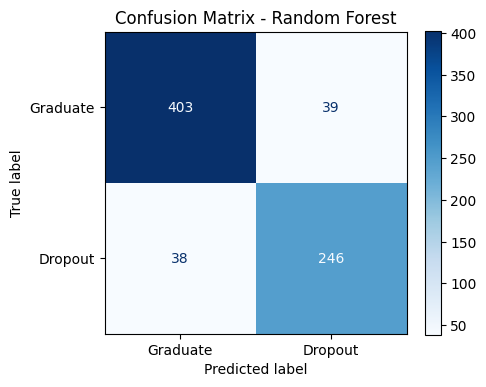

In [9]:
best_proba = best_model.predict_proba(X_test)[:, 1]
best_pred = (best_proba >= THRESHOLD).astype(int)

print(classification_report(y_test, best_pred, target_names=['Graduate', 'Dropout']))

cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred,
    display_labels=['Graduate', 'Dropout'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix - {BEST_MODEL_NAME}')
plt.tight_layout()
plt.show()


,Feature,Importance
4,num__Curricular_units_1st_sem_approved,0.284004
5,num__Curricular_units_1st_sem_grade,0.167040
0,num__Admission_grade,0.062494
3,num__Curricular_units_1st_sem_evaluations,0.060856
1,num__Age_at_enrollment,0.059504
31,cat__Tuition_fees_up_to_date_1,0.056101
30,cat__Tuition_fees_up_to_date_0,0.055967
2,num__Curricular_units_1st_sem_enrolled,0.033916
35,cat__Scholarship_holder_1,0.031301
34,cat__Scholarship_holder_0,0.030283


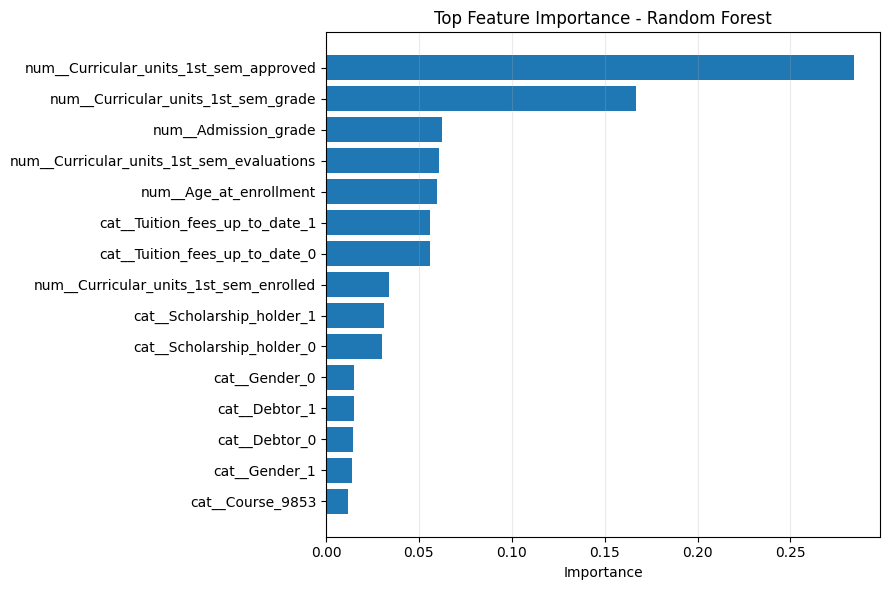

In [10]:
# Feature importance / coefficient magnitude untuk interpretasi model.
pre = best_model.named_steps['preprocessor']
feature_names = pre.get_feature_names_out()
est = best_model.named_steps['model']

if hasattr(est, 'feature_importances_'):
    importance = est.feature_importances_
elif hasattr(est, 'coef_'):
    importance = np.abs(est.coef_[0])
else:
    importance = np.zeros(len(feature_names))

fi = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    .sort_values('Importance', ascending=False)
    .head(15)
)

display(fi)

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = fi.sort_values('Importance', ascending=True)
ax.barh(plot_df['Feature'], plot_df['Importance'])
ax.set_title(f'Top Feature Importance - {BEST_MODEL_NAME}')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Menyimpan Model dan Data Dashboard

Cell berikut membuat artefak yang dibutuhkan untuk submission:
- `model/dropout_model.joblib` — pipeline preprocessing + model + metadata.
- `data/dashboard_student_performance.csv` — data yang sudah diperkaya untuk Looker Studio.

**Pastikan cell ini berhasil dijalankan sebelum membuat ZIP submission.**

In [11]:
Path('model').mkdir(exist_ok=True)
Path('data').mkdir(exist_ok=True)

artifact = {
    'model': best_model,
    'threshold': THRESHOLD,
    'features': FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'numeric_features': NUMERIC_FEATURES,
    'model_name': BEST_MODEL_NAME,
    'training_statuses': ['Graduate', 'Dropout'],
    'target_definition': 'Graduate=0, Dropout=1',
}
joblib.dump(artifact, 'model/dropout_model.joblib')
print('Model tersimpan: model/dropout_model.joblib')

COURSE_MAP = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing Management',
    9773: 'Journalism & Communication',
    9853: 'Basic Education',
    9991: 'Management (evening)',
}

dash = df.copy()
dash.insert(0, 'StudentId', np.arange(1, len(dash) + 1))
dash['Is_Dropout'] = (dash['Status'] == 'Dropout').astype(int)
dash['CourseName'] = dash['Course'].map(COURSE_MAP).fillna(dash['Course'].astype(str))
dash['AttendanceType'] = dash['Daytime_evening_attendance'].map({1: 'Daytime', 0: 'Evening'})
dash['TuitionStatus'] = dash['Tuition_fees_up_to_date'].map({1: 'Up to date', 0: 'Not up to date'})
dash['DebtorStatus'] = dash['Debtor'].map({1: 'Debtor', 0: 'Not debtor'})
dash['ScholarshipStatus'] = dash['Scholarship_holder'].map({1: 'Scholarship', 0: 'No scholarship'})
dash['GenderLabel'] = dash['Gender'].map({1: 'Male', 0: 'Female'})
dash['AgeGroup'] = pd.cut(
    dash['Age_at_enrollment'], [0, 20, 25, 30, 40, 100],
    labels=['<=20', '21-25', '26-30', '31-40', '41+']
).astype(str)
dash['FirstSemApprovalRate'] = np.where(
    dash['Curricular_units_1st_sem_enrolled'] > 0,
    dash['Curricular_units_1st_sem_approved'] / dash['Curricular_units_1st_sem_enrolled'], 0
)
dash['FirstSemApprovalBand'] = pd.cut(
    dash['FirstSemApprovalRate'], [-0.01, 0.25, 0.5, 0.75, 1.0],
    labels=['0-25%', '26-50%', '51-75%', '76-100%']
).astype(str)

dashboard_cols = [
    'StudentId', 'Status', 'Is_Dropout', 'Course', 'CourseName', 'AttendanceType',
    'TuitionStatus', 'DebtorStatus', 'ScholarshipStatus', 'GenderLabel',
    'Age_at_enrollment', 'AgeGroup', 'Admission_grade',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations',
    'FirstSemApprovalRate', 'FirstSemApprovalBand'
]
dash[dashboard_cols].to_csv('data/dashboard_student_performance.csv', index=False)
print('Dashboard data tersimpan: data/dashboard_student_performance.csv')


Model tersimpan: model/dropout_model.joblib
Dashboard data tersimpan: data/dashboard_student_performance.csv


## Conclusion

Proyek membangun kerangka early warning dropout dengan menggabungkan analisis deskriptif, business dashboard, dan machine learning. Untuk menjaga validitas target, model **hanya dilatih menggunakan mahasiswa dengan outcome final `Dropout` atau `Graduate`**. Sebanyak **794 mahasiswa berstatus `Enrolled` dikeluarkan dari training dan test** karena outcome akhirnya belum diketahui dan tidak boleh dianggap sebagai kelas negatif.

Dataset modeling terdiri dari **3.630 mahasiswa**: 2.209 `Graduate` (60,85%) dan 1.421 `Dropout` (39,15%). Target model adalah `Graduate = 0` dan `Dropout = 1`, dengan stratified train-test split 80:20.

Model terpilih adalah **Random Forest** dengan threshold 0,50. Pada test set 726 mahasiswa, model memperoleh **Accuracy 89,39%**, **Precision Dropout 86,32%**, **Recall Dropout 86,62%**, **F1-score Dropout 86,47%**, dan **ROC-AUC 94,83%**. Confusion matrix menghasilkan **TN=403, FP=39, FN=38, TP=246**.

Model menggunakan data yang tersedia paling lambat setelah semester pertama sehingga dapat dipakai sebagai *early warning*. Prediksi sebaiknya digunakan sebagai **decision-support**, bukan keputusan otomatis terhadap mahasiswa. Mahasiswa yang masih `Enrolled` dapat menjadi kandidat penggunaan model di masa mendatang setelah fitur semester pertama tersedia, tetapi label mereka tidak digunakan untuk training sampai outcome final diketahui.

### Rekomendasi Action Items
1. Prioritaskan monitoring mahasiswa dengan sinyal finansial bermasalah, terutama biaya kuliah tidak *up to date* atau status debtor.
2. Buat trigger intervensi akademik bagi mahasiswa dengan approval rate dan nilai semester pertama rendah.
3. Terapkan tier risiko dari prototype (rendah/sedang/tinggi) sebagai antrean prioritas konseling, bukan sebagai hukuman atau keputusan final.
4. Monitor performa model secara berkala karena pola mahasiswa dapat berubah; retraining perlu dilakukan ketika akurasi/recall menurun.
5. Gabungkan sinyal model dengan informasi kualitatif dari dosen wali/konselor agar intervensi lebih manusiawi dan tepat sasaran.

